Exploratory Data Analysis 

Roles to Explore

In [56]:
#Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading Dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Cleaning Data
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)


Filter Data Analyst Job Locations in USA

In [57]:
df_DA_US=df[(df['job_title_short']=='Data Analyst')&(df['job_country']=='United States')].copy()

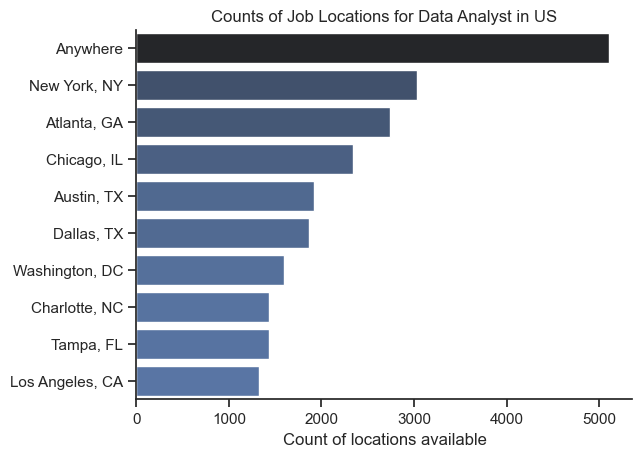

In [60]:
df_plot=df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location',hue='count',palette='dark:b_r',legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in US')
plt.xlabel('Count of locations available')
plt.ylabel('')
plt.show()

Job Opportunities

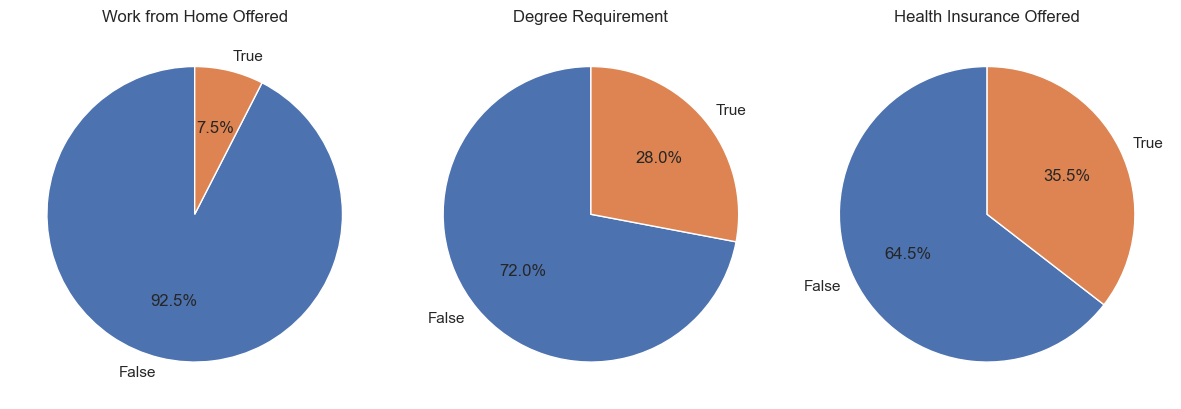

In [59]:
dict_col={
    'job_work_from_home':'Work from Home Offered',
    'job_no_degree_mention':'Degree Requirement',
    'job_health_insurance':'Health Insurance Offered'
}

fig,ax=plt.subplots(1,3)
fig.set_size_inches((12,5))

for i,(column,title) in enumerate(dict_col.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False','True'],autopct='%1.1f%%',startangle=90)
    ax[i].set_title(title)

fig.tight_layout()
plt.show()

Top Companies to Explore

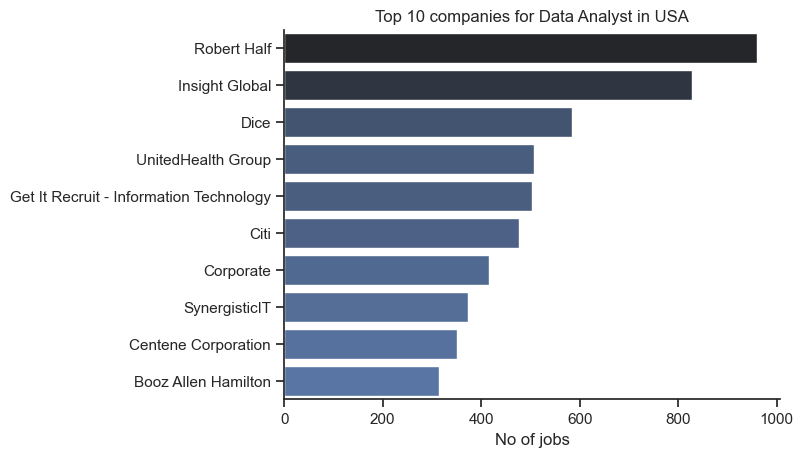

In [74]:
df_plot=df_DA_US['company_name'].value_counts().to_frame().head(10)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='company_name',hue='count',palette='dark:b_r')
sns.despine()
plt.title('Top 10 companies for Data Analyst in USA')
plt.legend().set_visible(False)
plt.xlabel('No of jobs')
plt.ylabel('')
plt.show()